# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thar-26/flyrank-ml-internship-2026/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [13]:
import os
import pandas as pd
import numpy as np

repo = "/content/flyrank-ml-internship"

# Clone the repo if it is not already available
if not os.path.exists(repo):
    !git clone https://github.com/thar-26/flyrank-ml-internship.git "$repo"

# Move into the repository
%cd /content/flyrank-ml-internship

# Load the dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset loaded successfully")
print("Rows:", len(df))
print("Clients:", df["client_id"].nunique())
print("Shape:", df.shape)

/content/flyrank-ml-internship
Dataset loaded successfully
Rows: 30000
Clients: 32
Shape: (30000, 44)


## 1. Question

### Research question and decision

My capstone focuses on Content Opportunity Scoring.

The main question is: **Which pages should be reviewed first for refresh or other content actions?**

The decision this supports is how a content team can prioritise its limited review time. Instead of looking at every page in the same order, the analysis ranks pages using observable search and content-performance signals.

The goal is not to automatically decide what should happen to a page. The output is a review priority list that a person can use to decide whether a page should be refreshed, improved, protected, monitored, or left alone.

The model is therefore a decision-support tool rather than an automatic content decision system.

In [14]:
print("Research question:")
print("Which pages should be reviewed first for refresh or other content actions?")

print("\nDecision supported:")
print(
    "The analysis helps prioritise which pages a content team should "
    "review first based on observable search and content-performance signals."
)

print("\nImportant limitation:")
print(
    "The score is a prioritisation aid, not a guarantee that refreshing "
    "a page will improve its performance."
)

Research question:
Which pages should be reviewed first for refresh or other content actions?

Decision supported:
The analysis helps prioritise which pages a content team should review first based on observable search and content-performance signals.

Important limitation:
The score is a prioritisation aid, not a guarantee that refreshing a page will improve its performance.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*
The dataset contains 30,000 rows across 32 clients and 44 available columns.

For the model, I use six page-level signals: 90-day impressions, days since last update, content age, average position, CTR, and engagement rate.

For evaluation, I use `trend_direction` to create a simple declining-page proxy. Pages with a "down" trend are labelled as declining.

I excluded identifiers and outcome-derived fields from the model features to reduce leakage risk.

The data is anonymized, and the public results will not include client names, domains, private queries, or raw data.

In [15]:
# Features used in the model
features = [
    "impressions_90d",
    "days_since_last_update",
    "content_age_days",
    "avg_position",
    "ctr",
    "engagement_rate",
]

# Create the evaluation label
df["is_declining_label"] = (
    df["trend_direction"].str.lower() == "down"
).astype(int)

print("Dataset shape:", df.shape)
print("Number of clients:", df["client_id"].nunique())
print("\nFeatures used:")
for feature in features:
    print("-", feature)

print(
    "\nDeclining pages:",
    df["is_declining_label"].sum()
)

print(
    "Declining rate:",
    round(df["is_declining_label"].mean(), 3)
)

display(df[features].head())

Dataset shape: (30000, 45)
Number of clients: 32

Features used:
- impressions_90d
- days_since_last_update
- content_age_days
- avg_position
- ctr
- engagement_rate

Declining pages: 16262
Declining rate: 0.542


,impressions_90d,days_since_last_update,content_age_days,avg_position,ctr,engagement_rate
0,3803,20,187,10.6,0.76,5.88
1,15320,25,445,20.3,0.05,0.00
2,12581,20,141,36.5,0.09,0.00
3,11751,22,463,6.2,0.49,1.28
4,19140,14,263,44.0,0.13,0.00


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
The analysis compares two models: Logistic Regression and Random Forest. I also compare them with the frozen Week-4 baseline.

I use a client-grouped 75/25 holdout split. This keeps pages from the same client together, so the same client does not appear in both the training and test sets.

The model uses the six features defined in the Data section. The target is the declining-page proxy created from `trend_direction`.

Random Forest is used to produce a score for each test page. Pages can then be ranked by this score for the content review queue.

For the leakage check, fields that directly describe the outcome or identify the page/client are not used as model features.

In [16]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

SEED = 42

X = df[features]
y = df["is_declining_label"]
groups = df["client_id"]

# Client-grouped 75/25 holdout
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=SEED
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Training rows: 22885
Test rows: 7115
Training clients: 24
Test clients: 8
Client overlap: 0


In [17]:
rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=SEED,
            n_jobs=-1
        )
    )
])

lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

rf_scores = rf.predict_proba(X_test)[:, 1]
lr_scores = lr.predict_proba(X_test)[:, 1]

print("Both models trained successfully.")

Both models trained successfully.



## 4. Results (vs baseline)

I compare the two models with the frozen Week-4 baseline using Precision@20 and Precision@50.

The Random Forest performed best at the top of the ranking. It achieved 0.900 Precision@20 and 0.700 Precision@50. Logistic Regression achieved 0.700 Precision@20 and 0.680 Precision@50.

The frozen Week-4 baseline achieved 0.200 Precision@20 and 0.300 Precision@50.

The Random Forest therefore gives the strongest ranking result on this client-grouped test split. These results are measured on this evaluation split and should not be treated as a guarantee of future performance.

In [18]:
import numpy as np
import pandas as pd

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return np.asarray(labels)[order].mean()

y_test_array = y_test.to_numpy()

lr_p20 = precision_at_k(lr_scores, y_test_array, 20)
lr_p50 = precision_at_k(lr_scores, y_test_array, 50)

rf_p20 = precision_at_k(rf_scores, y_test_array, 20)
rf_p50 = precision_at_k(rf_scores, y_test_array, 50)

results = pd.DataFrame({
    "Method": [
        "Frozen Week-4 baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision@20": [
        0.200,
        lr_p20,
        rf_p20
    ],
    "Precision@50": [
        0.300,
        lr_p50,
        rf_p50
    ]
})

display(results)

,Method,Precision@20,Precision@50
0,Frozen Week-4 baseline,0.2,0.30
1,Logistic Regression,0.7,0.68
2,Random Forest,0.9,0.70


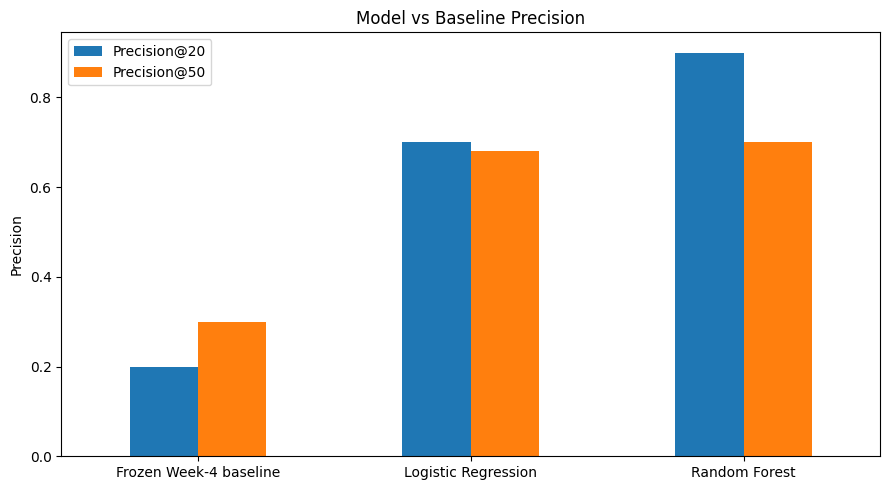

In [19]:
import matplotlib.pyplot as plt

results.set_index("Method")[
    ["Precision@20", "Precision@50"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model vs Baseline Precision")
plt.ylabel("Precision")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## 5. Limitations
There are a few important limitations to this analysis.

First, the model was evaluated on one client-grouped holdout split. The results therefore show how the model performed on this test split, but they do not guarantee the same performance on future data.

Second, the target is an evaluation proxy based on observed trend direction. It does not directly measure whether a page actually needs to be refreshed.

Third, the available timestamp information does not allow me to fully prove that every feature window is non-overlapping with the label window.

Finally, the model identifies patterns associated with declining pages. It does not prove that refreshing a page will cause its search performance to improve.

Because of these limitations, the model should be used as a decision-support tool. The final decision should always be made by a human reviewer.

## 6. Ranked recommendations
The model output is used to prioritise pages for human review.

High-scoring pages should be reviewed first, especially when they also have meaningful search visibility. The score is a prioritisation signal and does not automatically decide what action should be taken.

The main actions are to review a page for a possible refresh, check metadata or content, monitor it, or leave it unchanged.

A human reviewer makes the final decision. The system should not automatically publish, rewrite, delete, merge, or redirect content.

## 7. Artifacts the paper embeds

The main artifacts for the final paper are the model comparison results and the feature-importance analysis.

The paper will use these to show how the Random Forest performed compared with the baseline and Logistic Regression.

The ranked recommendations come from the Week 7 action playbook.

The public paper will only show safe, anonymized results. Raw data, client information, private queries, and other sensitive details will not be published.

In [20]:
# Show the main model results for the paper

display(results)

,Method,Precision@20,Precision@50
0,Frozen Week-4 baseline,0.2,0.30
1,Logistic Regression,0.7,0.68
2,Random Forest,0.9,0.70


In [21]:
# Random Forest feature importance

rf_model = rf.named_steps["model"]

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
0,impressions_90d,0.308593
2,content_age_days,0.245507
3,avg_position,0.236044
4,ctr,0.104988
1,days_since_last_update,0.056217
5,engagement_rate,0.048650


## Self-check

- [x] Question is clear and supports a real decision
- [x] Data and selected features are documented
- [x] Baseline and model comparison are included
- [x] Client-grouped validation is used
- [x] Leakage risks are discussed
- [x] Results use measured values from the evaluation
- [x] Limitations are stated honestly
- [x] Ranked recommendations are included
- [x] Human review and no-go cases are explained
- [x] Artifacts for the final paper are identified
- [x] Final research paper deployed
- [x] `submission/paper_url.txt` added with the paper URL
- [x] Final paper linked to the repository